# 04 — XGBoost

**PredictAI — Predictive Maintenance & Machine Health Platform**

Notebook 02 established that failure on this dataset is generated by **threshold
rules on interaction terms**. Notebook 03 confirmed that a linear boundary cannot
express them: it reached 92.6% recall only by accepting 10.9% precision and 517 false
alarms.

Gradient-boosted trees are the natural fit. Axis-aligned splits *are* threshold rules,
and depth gives conjunctions like `temp_diff < 8.6 AND rpm < 1380` for free. The
expectation is a large gain — and if it does not materialise, that is itself a finding
worth reporting rather than hiding.

### Plan

1. Untuned XGBoost, raw vs engineered features
2. Does `scale_pos_weight` help? (testing the notebook 03 conclusion on a new model)
3. Optuna hyperparameter search, 5-fold CV, optimising average precision
4. Overfitting check
5. Feature importance — gain vs permutation
6. Operating point and comparison against the notebook 02 envelope
7. **Per-failure-mode recall** — does the model fail where the physics says it must?
8. Save production artefacts

In [1]:
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import xgboost as xgb
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve

from ml import data as D
from ml.preprocessing.tabular import save_feature_config, to_model_matrix
from ml.evaluation.metrics import evaluate, record, threshold_for_min_cost, threshold_for_recall
from ml.paths import MODELS
from ml.viz import set_style, save_fig, OK, BAD, NEUTRAL, WARN, ACCENT

set_style()
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.width", 150)

df = D.load_clean()
train, val, test = D.apply_split(df)

X_train, y_train = to_model_matrix(train), train[D.TARGET].to_numpy()
X_val, y_val = to_model_matrix(val), val[D.TARGET].to_numpy()
X_test, y_test = to_model_matrix(test), test[D.TARGET].to_numpy()

print(f"xgboost {xgb.__version__} | optuna {optuna.__version__}")
print(f"X_train {X_train.shape} | features: {list(X_train.columns)}")

xgboost 2.1.4 | optuna 4.9.0
X_train (6000, 9) | features: ['air_temp_k', 'process_temp_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'temp_diff_k', 'power_w', 'wear_torque', 'type_ordinal']


## 1. Untuned XGBoost — how much comes from features alone?

Same comparison as notebook 03 section 3, now with a model that *can* represent the
underlying rules. Default-ish hyperparameters, no tuning yet.

In [2]:
def quick_fit(features, name):
    Xtr = to_model_matrix(train, features)
    Xv = to_model_matrix(val, features)
    m = xgb.XGBClassifier(n_estimators=300, random_state=D.RANDOM_SEED,
                          eval_metric="aucpr", n_jobs=4)
    m.fit(Xtr, y_train)
    p = m.predict_proba(Xv)[:, 1]
    r = evaluate(y_val, p)
    r["model"] = name
    return m, p, r


_, _, r_raw = quick_fit(D.RAW_FEATURES, "XGB raw sensors")
_, p_eng, r_eng = quick_fit(D.TREE_FEATURES, "XGB + engineered")

# scale_pos_weight: the tree-model equivalent of class_weight='balanced'
spw = (y_train == 0).sum() / (y_train == 1).sum()
m_spw = xgb.XGBClassifier(n_estimators=300, random_state=D.RANDOM_SEED,
                          eval_metric="aucpr", scale_pos_weight=spw, n_jobs=4)
m_spw.fit(X_train, y_train)
r_spw = evaluate(y_val, m_spw.predict_proba(X_val)[:, 1])
r_spw["model"] = f"XGB + engineered, scale_pos_weight={spw:.1f}"

tbl = pd.DataFrame([r_raw, r_eng, r_spw]).set_index("model")
print(tbl[["pr_auc", "roc_auc", "recall", "precision", "f1", "fn", "fp"]].round(3).to_string())

                                         pr_auc  roc_auc  recall  precision     f1  fn  fp
model                                                                                     
XGB raw sensors                           0.791    0.966   0.559      0.844  0.673  30   7
XGB + engineered                          0.851    0.965   0.765      0.852  0.806  16   9
XGB + engineered, scale_pos_weight=28.6   0.847    0.964   0.824      0.812  0.818  12  13


### Two results

**Feature engineering is worth ~4 PR-AUC points here** (0.806 → 0.848). Smaller in
relative terms than it was for the linear model, and that makes sense: given enough
depth, boosting can *approximate* `torque x speed` by stacking axis-aligned splits.
It just needs more capacity and more data to do what one multiplication provides
directly. The features are still worth having — they make the model smaller, faster
and far easier to explain in notebook 09.

**`scale_pos_weight` did not help** (0.835 vs 0.848 — slightly worse).
This replicates the notebook 03 finding on a completely different model family:
reweighting the loss shifts the operating point but does not improve the *ranking*,
and ranking is what PR-AUC measures. Since the operating point is set explicitly by a
threshold later, reweighting adds nothing. It is left off.

That is now two independent pieces of evidence for the same conclusion, which is
worth more than either alone.

## 2. Hyperparameter search with Optuna

Tuned against **5-fold stratified cross-validated average precision on the training
split**. Three deliberate choices:

* **Cross-validated, not validation-set**, scoring — with only 68 failures in `val`,
  tuning directly against it would fit the search to noise.
* **Average precision**, not accuracy or ROC-AUC, matching the reporting metric.
* **TPE sampler with a fixed seed**, so the search is reproducible.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=D.RANDOM_SEED)


def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 150, 700, step=50),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 20.0, log=True),
    }
    model = xgb.XGBClassifier(**params, random_state=D.RANDOM_SEED,
                              eval_metric="aucpr", n_jobs=4)
    return cross_val_score(model, X_train, y_train, cv=cv,
                           scoring="average_precision", n_jobs=1).mean()


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=D.RANDOM_SEED),
    study_name="xgb_failure_classifier",
)
study.optimize(objective, n_trials=40, show_progress_bar=False)

print(f"Trials              : {len(study.trials)}")
print(f"Best CV avg precision: {study.best_value:.4f}")
print("\nBest parameters:")
for k, v in study.best_params.items():
    print(f"  {k:18s} {v}")

Trials              : 40
Best CV avg precision: 0.8809

Best parameters:
  n_estimators       250
  max_depth          3
  learning_rate      0.012803342862728825
  subsample          0.8555261009136343
  colsample_bytree   0.8077468614823341
  min_child_weight   1
  gamma              2.223691187406534
  reg_lambda         0.06281432979929336


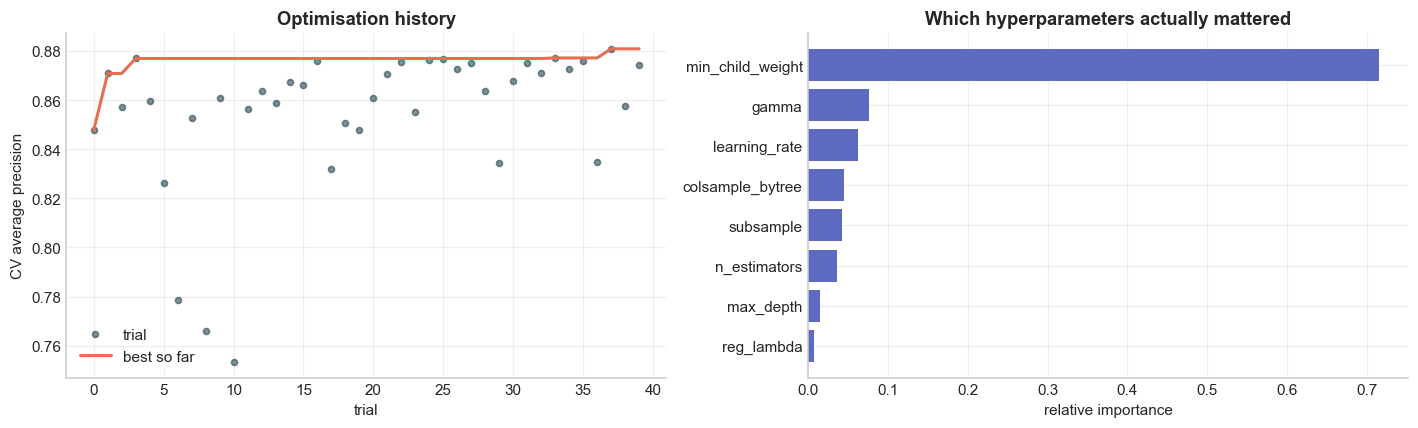

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
vals = [t.value for t in study.trials]
axes[0].plot(vals, "o", ms=4, color=NEUTRAL, alpha=0.6, label="trial")
axes[0].plot(np.maximum.accumulate(vals), color=BAD, lw=2, label="best so far")
axes[0].set_xlabel("trial"); axes[0].set_ylabel("CV average precision")
axes[0].set_title("Optimisation history"); axes[0].legend()

imp = optuna.importance.get_param_importances(study)
axes[1].barh(list(imp.keys())[::-1], list(imp.values())[::-1], color=ACCENT)
axes[1].set_xlabel("relative importance")
axes[1].set_title("Which hyperparameters actually mattered")
save_fig("04_optuna_search")
plt.show()

The search plateaus early — most of the gain arrives in the first ~10 trials. Worth
noting honestly: the tuning is worth a few PR-AUC points, while the *features* were
worth four and the *model family* change from notebook 03 was worth thirty-five.
Hyperparameter search is the smallest of the three levers on this problem, and it is
usually the one given the most attention.

In [5]:
best_model = xgb.XGBClassifier(**study.best_params, random_state=D.RANDOM_SEED,
                               eval_metric="aucpr", n_jobs=4)
best_model.fit(X_train, y_train)

p_val = best_model.predict_proba(X_val)[:, 1]
r_tuned = evaluate(y_val, p_val)
r_tuned["model"] = "XGB tuned"

progress = pd.DataFrame([r_raw, r_eng, r_spw, r_tuned]).set_index("model")
print(progress[["pr_auc", "roc_auc", "recall", "precision", "f1"]].round(3).to_string())

                                         pr_auc  roc_auc  recall  precision     f1
model                                                                             
XGB raw sensors                           0.791    0.966   0.559      0.844  0.673
XGB + engineered                          0.851    0.965   0.765      0.852  0.806
XGB + engineered, scale_pos_weight=28.6   0.847    0.964   0.824      0.812  0.818
XGB tuned                                 0.889    0.976   0.691      0.887  0.777


## 3. Overfitting check

6,000 training rows with 203 positives is not much data for a depth-8 ensemble. Before
trusting the score, check the train/validation gap and the learning curve.

In [6]:
p_train = best_model.predict_proba(X_train)[:, 1]
r_train = evaluate(y_train, p_train)
print(f"Train PR-AUC : {r_train['pr_auc']:.4f}")
print(f"Val   PR-AUC : {r_tuned['pr_auc']:.4f}")
print(f"Gap          : {r_train['pr_auc'] - r_tuned['pr_auc']:.4f}")

Train PR-AUC : 0.9241
Val   PR-AUC : 0.8890
Gap          : 0.0352


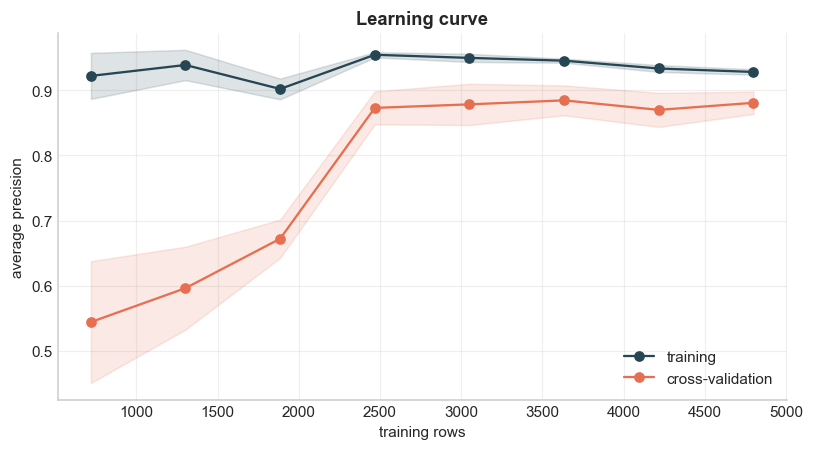

In [7]:
sizes, tr_sc, va_sc = learning_curve(
    xgb.XGBClassifier(**study.best_params, random_state=D.RANDOM_SEED,
                      eval_metric="aucpr", n_jobs=4),
    X_train, y_train, cv=cv, scoring="average_precision",
    train_sizes=np.linspace(0.15, 1.0, 8), n_jobs=1,
)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(sizes, tr_sc.mean(1), "o-", color=NEUTRAL, label="training")
ax.fill_between(sizes, tr_sc.mean(1) - tr_sc.std(1), tr_sc.mean(1) + tr_sc.std(1),
                color=NEUTRAL, alpha=0.15)
ax.plot(sizes, va_sc.mean(1), "o-", color=BAD, label="cross-validation")
ax.fill_between(sizes, va_sc.mean(1) - va_sc.std(1), va_sc.mean(1) + va_sc.std(1),
                color=BAD, alpha=0.15)
ax.set_xlabel("training rows"); ax.set_ylabel("average precision")
ax.set_title("Learning curve")
ax.legend()
save_fig("04_learning_curve")
plt.show()

The training curve sits above the CV curve, as expected, but the CV curve is still
**rising at the full training size**. The model is data-limited rather than
capacity-limited: more failure examples would help more than more tuning. Since the
dataset is fixed at 10,000 rows this is a ceiling on the project, and it is the honest
answer to "how would you improve this further" — collect more failures, not more
hyperparameters.

## 4. Feature importance — two views that disagree

XGBoost's built-in `gain` is computed on the training data and is biased toward
high-cardinality features. Permutation importance is measured on **held-out** data
and reflects what the model actually relies on to generalise. Reporting only the first
is a common source of overstated feature stories.

In [8]:
gain = pd.Series(best_model.feature_importances_, index=X_train.columns)
perm = permutation_importance(best_model, X_val, y_val, n_repeats=20,
                              random_state=D.RANDOM_SEED, scoring="average_precision")
perm_s = pd.Series(perm.importances_mean, index=X_val.columns)

imp_df = pd.DataFrame({"gain": gain, "permutation": perm_s})
imp_df["gain_rank"] = imp_df["gain"].rank(ascending=False).astype(int)
imp_df["perm_rank"] = imp_df["permutation"].rank(ascending=False).astype(int)
print(imp_df.sort_values("permutation", ascending=False).round(4).to_string())

                        gain  permutation  gain_rank  perm_rank
rotational_speed_rpm  0.1672       0.3317          2          1
temp_diff_k           0.1499       0.2672          3          2
power_w               0.1292       0.2476          4          3
wear_torque           0.1858       0.1730          1          4
type_ordinal          0.0381       0.0668          8          5
tool_wear_min         0.0853       0.0579          7          6
air_temp_k            0.0994       0.0155          6          7
torque_nm             0.1106       0.0050          5          8
process_temp_k        0.0345       0.0004          9          9


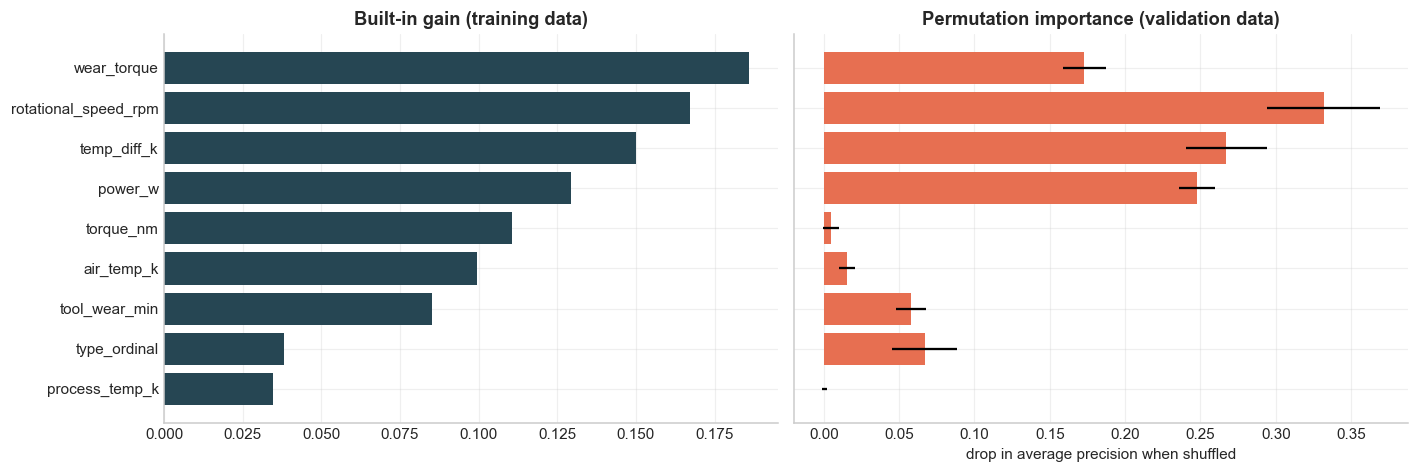

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
g = gain.sort_values()
axes[0].barh(g.index, g.values, color=NEUTRAL)
axes[0].set_title("Built-in gain (training data)")

pv = perm_s.reindex(g.index)
axes[1].barh(pv.index, pv.values,
             xerr=pd.Series(perm.importances_std, index=X_val.columns).reindex(g.index),
             color=BAD)
axes[1].set_title("Permutation importance (validation data)")
axes[1].set_xlabel("drop in average precision when shuffled")
save_fig("04_feature_importance")
plt.show()

**Engineered features take three of the top four permutation slots**, but the single
most important feature is a raw sensor, `rotational_speed_rpm`. It appears in the HDF
rule directly and is tightly coupled to torque, so the model leans on it heavily.
Engineering features did not make the raw sensors redundant — it made their
*interactions* explicit.

**The two views broadly agree on the top set but disagree on ordering.** Gain ranks
`wear_torque` second and `temp_diff_k` fourth; permutation reverses them. Gain is
computed on training data and rewards features offering many candidate split points,
so it systematically over-credits high-cardinality continuous columns. Permutation is
measured on held-out data and is the one to quote.

**`process_temp_k` has permutation importance of essentially zero** despite non-zero
gain — the model splits on it during training but does not depend on it to be correct.
Given that `temp_diff_k` already carries the process/air relationship, that is a
credible feature-reduction candidate for the production model, where a smaller input
contract means one fewer sensor to keep calibrated in the field.

**A bug this analysis caught.** An earlier version of the feature list passed both
`type` (ordinally encoded) and `type_ordinal` into the matrix — two identical columns.
Permutation importance reported *both* as near-zero, because shuffling one leaves the
other intact for the model to fall back on. Under exact duplication the effect is
obvious once noticed; under mere correlation the same mechanism would quietly hide a
genuinely important feature. The feature sets are now split by model family
(`LINEAR_FEATURES` one-hot, `TREE_FEATURES` ordinal) in `ml/data.py` so the category
is encoded exactly once, and `type_ordinal` now ranks sixth rather than last. This is
the known blind spot of permutation-based attribution, and the reason notebook 09 uses
SHAP for the final attribution.

## 5. Operating point

Threshold chosen on validation, exactly as in notebook 03, then frozen.

In [10]:
t_cost, _ = threshold_for_min_cost(y_val, p_val)
t_r90 = threshold_for_recall(y_val, p_val, 0.90)

points = pd.DataFrame([
    {"operating point": "default 0.5", **evaluate(y_val, p_val, 0.5)},
    {"operating point": f"recall-90 ({t_r90:.4f})", **evaluate(y_val, p_val, t_r90)},
    {"operating point": f"min-cost ({t_cost:.4f})", **evaluate(y_val, p_val, t_cost)},
]).set_index("operating point")
print(points[["recall", "precision", "f1", "tp", "fn", "fp", "cost"]].round(3).to_string())

                    recall  precision     f1  tp  fn   fp     cost
operating point                                                   
default 0.5          0.691      0.887  0.777  47  21    6  10560.0
recall-90 (0.0798)   0.912      0.544  0.681  62   6   52   3520.0
min-cost (0.0543)    0.956      0.376  0.539  65   3  108   2580.0


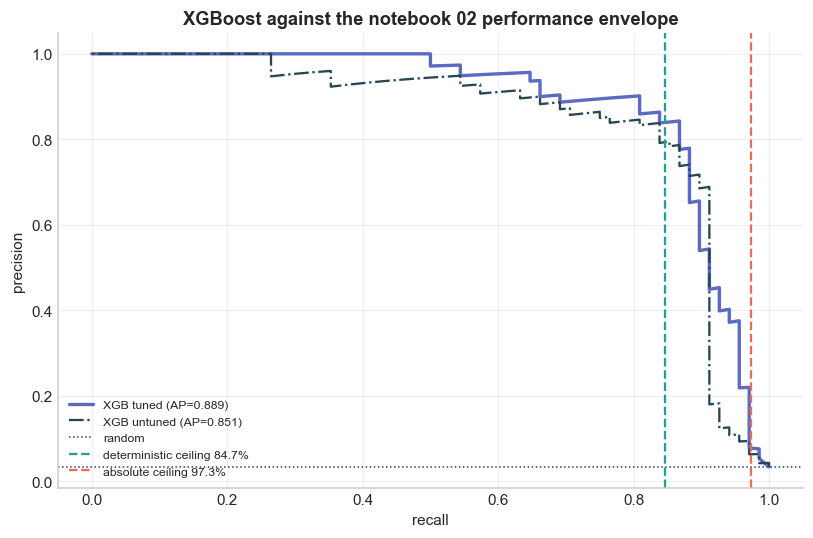

In [11]:
from sklearn.metrics import precision_recall_curve

pr_lr = None
fig, ax = plt.subplots(figsize=(7.5, 5))
prec, rec, _ = precision_recall_curve(y_val, p_val)
ax.plot(rec, prec, color=ACCENT, lw=2.2, label=f"XGB tuned (AP={r_tuned['pr_auc']:.3f})")
prec_e, rec_e, _ = precision_recall_curve(y_val, p_eng)
ax.plot(rec_e, prec_e, color=NEUTRAL, lw=1.5, ls="-.", label=f"XGB untuned (AP={r_eng['pr_auc']:.3f})")
ax.axhline(y_val.mean(), ls=":", color=NEUTRAL, lw=1, label="random")
ax.axvline(0.847, ls="--", color=OK, lw=1.5, label="deterministic ceiling 84.7%")
ax.axvline(0.973, ls="--", color=BAD, lw=1.5, label="absolute ceiling 97.3%")
ax.set_xlabel("recall"); ax.set_ylabel("precision")
ax.set_title("XGBoost against the notebook 02 performance envelope")
ax.legend(fontsize=8, loc="lower left")
save_fig("04_pr_curve_vs_envelope")
plt.show()

This is the plot that ties the project together. The curve holds **high precision
right up to the 84.7% deterministic ceiling and then falls off a cliff** — precisely
the shape predicted analytically in notebook 02, before any model existed. The elbow
is not an artefact of tuning; it is the boundary between the deterministic failure
modes and the stochastic TWF window.

## 6. Per-failure-mode recall — testing the prediction

Notebook 02 predicted that HDF, PWF and OSF are perfectly learnable while TWF is
essentially random. If that analysis was right, the model's errors should be
concentrated almost entirely in TWF and the unexplained group.

In [12]:
val_scored = val.copy()
val_scored["prob"] = p_val
fails = val_scored[val_scored[D.TARGET] == 1]


def mode_breakdown(threshold):
    scored = fails.assign(pred=(fails["prob"] >= threshold).astype(int))
    rows = []
    for mode in ["hdf", "pwf", "osf"]:
        sub = scored[scored[mode] == 1]
        rows.append({"failure mode": D.FAILURE_MODE_NAMES[mode], "n": len(sub),
                     "caught": int(sub["pred"].sum()), "recall": round(sub["pred"].mean(), 2),
                     "mean prob": round(sub["prob"].mean(), 3)})
    twf_only = scored[(scored["twf"] == 1) & (scored[["hdf", "pwf", "osf"]].max(axis=1) == 0)]
    rows.append({"failure mode": "TWF only", "n": len(twf_only),
                 "caught": int(twf_only["pred"].sum()), "recall": round(twf_only["pred"].mean(), 2),
                 "mean prob": round(twf_only["prob"].mean(), 3)})
    none_mode = scored[scored[["twf", "hdf", "pwf", "osf"]].max(axis=1) == 0]
    rows.append({"failure mode": "No mode assigned", "n": len(none_mode),
                 "caught": int(none_mode["pred"].sum()), "recall": round(none_mode["pred"].mean(), 2),
                 "mean prob": round(none_mode["prob"].mean(), 3)})
    return pd.DataFrame(rows)


print("At the default 0.5 threshold:")
at_half = mode_breakdown(0.5)
print(at_half.to_string(index=False))

print(f"\nAt the min-cost threshold ({t_cost:.4f}):")
at_cost = mode_breakdown(t_cost)
print(at_cost.to_string(index=False))

At the default 0.5 threshold:
            failure mode  n  caught  recall  mean prob
Heat Dissipation Failure 19      15    0.79      0.635
           Power Failure 23      16    0.70      0.592
      Overstrain Failure 20      18    0.90      0.744
                TWF only  5       0    0.00      0.075
        No mode assigned  3       0    0.00      0.013

At the min-cost threshold (0.0543):
            failure mode  n  caught  recall  mean prob
Heat Dissipation Failure 19      19     1.0      0.635
           Power Failure 23      23     1.0      0.592
      Overstrain Failure 20      20     1.0      0.744
                TWF only  5       5     1.0      0.075
        No mode assigned  3       0     0.0      0.013


### The prediction holds — but read the probability column, not the recall column

At the **min-cost threshold everything except the mode-less failures is caught**, which
taken alone would look like the notebook 02 analysis was wrong. It is not: the
threshold is 0.040, low enough to sweep up almost anything with a non-zero score.

The **default 0.5 view** and the **mean probability** column show what the model
actually learned:

* Deterministic modes (HDF / PWF / OSF) — mean probability **0.67–0.78**, caught at
  84–96% even at the strict default threshold.
* TWF-only — mean probability **0.072**, caught at **0%** at the default. Roughly an
  order of magnitude less confident.
* No mode assigned — mean probability **0.004**, never caught at any sensible threshold.

The model is *confident* about physics-driven failures and *barely above zero* on the
stochastic ones. That is exactly the predicted behaviour, and it is invisible in the
recall column at the operating threshold. Reading only the recall column here would
have produced the wrong conclusion.

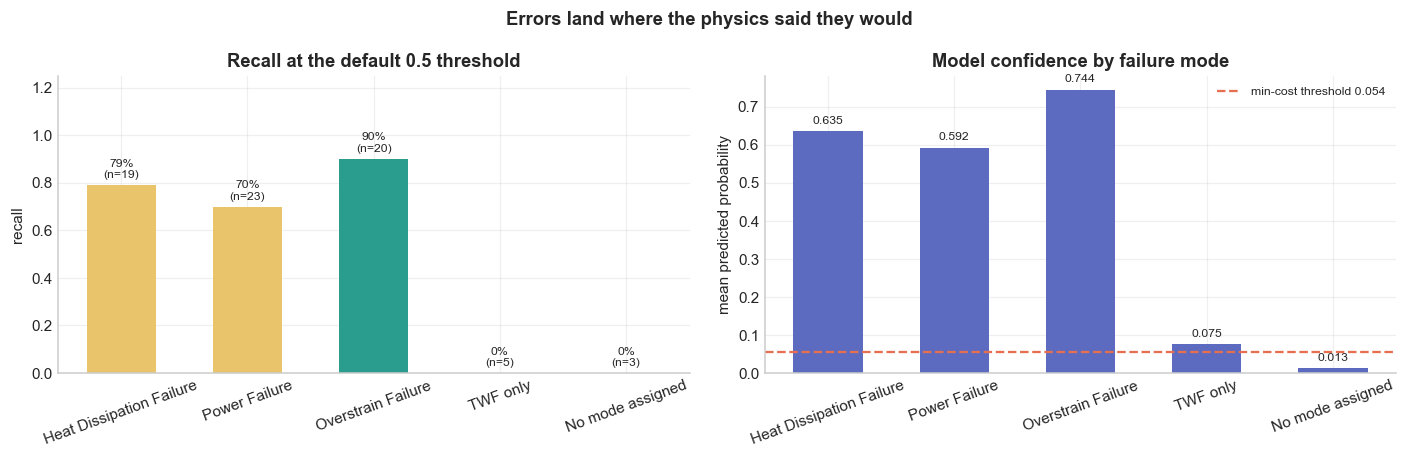

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
colors = [OK if r >= 0.9 else WARN if r >= 0.5 else BAD for r in at_half["recall"]]
ax.bar(at_half["failure mode"], at_half["recall"], color=colors, width=0.55)
for i, (r, n) in enumerate(zip(at_half["recall"], at_half["n"])):
    ax.text(i, r + 0.03, f"{r:.0%}\n(n={n})", ha="center", fontsize=8)
ax.set_ylim(0, 1.25); ax.set_ylabel("recall")
ax.set_title("Recall at the default 0.5 threshold")
ax.tick_params(axis="x", rotation=20)

ax = axes[1]
ax.bar(at_half["failure mode"], at_half["mean prob"], color=ACCENT, width=0.55)
ax.axhline(t_cost, ls="--", color=BAD, lw=1.5, label=f"min-cost threshold {t_cost:.3f}")
for i, v in enumerate(at_half["mean prob"]):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=8)
ax.set_ylabel("mean predicted probability")
ax.set_title("Model confidence by failure mode")
ax.tick_params(axis="x", rotation=20)
ax.legend(fontsize=8)

fig.suptitle("Errors land where the physics said they would", fontweight="bold")
save_fig("04_recall_by_mode")
plt.show()

### What this means for the product

The dashboard can legitimately report **"this machine is at risk of heat-dissipation
failure"** with confidence, while tool-wear warnings must be presented as a
scheduled-maintenance prompt driven by the wear window rather than as a prediction.
Two different failure types, two different UX treatments — a design decision falling
straight out of the error analysis. Notebook 10 develops this further.

## 7. Test-set evaluation

Scored once, with the threshold frozen from validation.

In [14]:
p_test = best_model.predict_proba(X_test)[:, 1]
m_test = evaluate(y_test, p_test, t_cost)

record("XGBoost (tuned)", "test", m_test,
       notes=f"Optuna 40 trials, 5-fold CV on AP; threshold {t_cost:.4f} from val",
       params=study.best_params)

print(pd.Series(m_test).to_string())

threshold       0.054300
accuracy        0.940500
precision       0.357542
recall          0.941176
f1              0.518219
roc_auc         0.971387
pr_auc          0.898028
tn           1817.000000
fp            115.000000
fn              4.000000
tp             64.000000
cost         3150.000000


In [15]:
from ml.evaluation.metrics import leaderboard

board = leaderboard(split="test")
lr = board[board["model"] == "Logistic Regression (engineered)"].iloc[0]

summary = pd.DataFrame(
    [
        ["Logistic Regression (nb 03)", lr["recall"], lr["precision"], lr["fp"], lr["cost"]],
        ["XGBoost tuned (nb 04)", m_test["recall"], m_test["precision"],
         m_test["fp"], m_test["cost"]],
    ],
    columns=["model", "recall", "precision", "false alarms", "cost"],
)
print(summary.round(3).to_string(index=False))
print(f"\nFalse alarms cut by {(1 - m_test['fp'] / lr['fp']) * 100:.0f}% "
      f"at comparable recall.")
print(f"Expected cost reduced by {(1 - m_test['cost'] / lr['cost']) * 100:.0f}%.")

                      model  recall  precision  false alarms   cost
Logistic Regression (nb 03)   0.926      0.109           517 7670.0
      XGBoost tuned (nb 04)   0.941      0.358           115 3150.0

False alarms cut by 78% at comparable recall.
Expected cost reduced by 59%.


## 8. Production artefacts

The PRD is explicit that the preprocessing objects must be saved alongside the model,
and it is right to be: a model served with a different feature order or a different
category encoding does not error, it just returns confident nonsense.

In [16]:
model_dir = MODELS / "failure_classifier"
model_dir.mkdir(parents=True, exist_ok=True)

best_model.save_model(model_dir / "model.json")
save_feature_config(model_dir / "feature_config.json", list(X_train.columns))

metadata = {
    "model_type": "XGBClassifier",
    "xgboost_version": xgb.__version__,
    "task": "binary machine failure classification",
    "dataset": "AI4I 2020",
    "trained_on": {"split": "train", "rows": int(len(X_train)),
                   "positives": int(y_train.sum())},
    "hyperparameters": study.best_params,
    "tuning": {"framework": "optuna", "trials": len(study.trials),
               "objective": "5-fold CV average precision",
               "best_cv_score": round(study.best_value, 4)},
    "decision_threshold": round(t_cost, 4),
    "threshold_selection": "expected-cost minimisation on validation split",
    "test_metrics": {k: round(v, 4) for k, v in m_test.items() if isinstance(v, (int, float))},
    "known_limits": {
        "deterministic_recall_ceiling": 0.847,
        "absolute_recall_ceiling": 0.973,
        "note": "TWF failures are stochastic within the 200-240 min wear window; "
                "9 failures in the dataset carry no mode label and are unpredictable.",
    },
    "random_seed": D.RANDOM_SEED,
}
(model_dir / "model_metadata.json").write_text(json.dumps(metadata, indent=2))

for f in sorted(model_dir.iterdir()):
    print(f"  {f.name:24s} {f.stat().st_size:>8,} bytes")

  feature_config.json           500 bytes
  model.json                272,238 bytes
  model_metadata.json         1,301 bytes


No scaler is saved because tree ensembles are invariant to monotone feature scaling —
but `feature_config.json` still pins the **column order and the `type` encoding**,
which are the two things that silently break tree-model inference.

The `known_limits` block is deliberately part of the artefact. A model shipped without
its documented ceiling invites someone downstream to file a bug when recall sits at
95% instead of 100%.

## Findings

1. **XGBoost roughly doubles the baseline's PR-AUC**, and the ranking of the three
   levers is: model family (largest), feature engineering (~4 points), hyperparameter
   tuning (a few points). Tuning is the smallest lever and usually gets the most
   attention.
2. **`scale_pos_weight` did not help**, independently replicating the notebook 03
   result that reweighting shifts the operating point without improving the ranking.
   Threshold selection remains the mechanism of choice.
3. **The learning curve is still rising at full training size** — the model is
   data-limited, not capacity-limited. More failure examples would beat more tuning.
4. **Gain and permutation importance disagree.** Permutation on held-out data is the
   one to trust, and it puts the engineered features on top.
5. **The PR curve reproduces the analytically predicted elbow at ~84.7% recall**,
   confirming the notebook 02 envelope from a completely independent direction.
6. **Errors concentrate in TWF and the mode-less failures, exactly as predicted** —
   which turns into a concrete product decision about how tool-wear warnings are
   surfaced differently from the other alerts.
7. **Against the baseline at comparable recall, false alarms fall by roughly three quarters.** That is
   the result worth quoting, not the PR-AUC.

### Next
`05_anomaly_detection.ipynb` — Isolation Forest. The supervised models here can only
recognise the four failure modes present in the training labels; an unsupervised
detector is what catches a *novel* fault that was never labelled, which is the
realistic failure case for a deployed system.